# 3.2 — Model Analysis & Explanation (Best Pipeline)

This notebook analyses and explains the winning **(dataset × model)** pair selected in `3.1-Data-Modelling-Regression.ipynb`.

It loads all trained results from the shared cache (`./models/all_results_cache.joblib`) so it  
**can be run independently** — no need to re-train anything.

## Outline

| # | Section |
|---|---|
| 1 | Imports & load best pipeline from cache |
| 2 | Residual analysis — best pipeline |
| 3 | Feature importance & SHAP — best pipeline |
| 4 | Dummy patient prediction — best pipeline |
| 5 | Save all models and metrics |

## 1. Imports & Load Best Pipeline from Cache

In [1]:
from pathlib import Path
import joblib
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import shap
except Exception:
    shap = None

print('Libraries loaded. SHAP available:', shap is not None)

Libraries loaded. SHAP available: True


In [2]:
# ── Load both results caches ──────────────────────────────────────────────────
_PATH_31 = Path('./models/all_results_cache.joblib')        # 3.1 baseline
_PATH_33 = Path('./models/3.3-all_results_cache.joblib')    # 3.2/3.3 tuned + stacking

def _load_cache(path, label):
    if not path.exists():
        print(f'⚠  {label} cache not found at {path} — skipping.')
        return {}
    data = joblib.load(path)
    print(f'Loaded {label}: {sum(len(v) for v in data.values())} runs from {path}')
    for ds, models_dict in data.items():
        for mdl, r in models_dict.items():
            print(f'  ✓  {ds:22s} × {mdl:<22s}  Test RMSE={r["test_rmse"]:.4f}  R²={r["test_r2"]:.4f}')
    return data

print('=== 3.1 Baseline ===')
results_31 = _load_cache(_PATH_31, '3.1-Baseline')
print()
print('=== 3.2/3.3 Tuned + Stacking ===')
results_33 = _load_cache(_PATH_33, '3.3-Tuned')

# Merge both under a single dict keyed by (source, dataset, model) for downstream use
all_results = {}
for source, cache in [('3.1-Baseline', results_31), ('3.3-Tuned', results_33)]:
    for ds, models_dict in cache.items():
        for mdl, res in models_dict.items():
            tagged_key = f'{source}|{ds}'
            all_results.setdefault(tagged_key, {})[mdl] = {**res, '_source': source, '_dataset': ds}

=== 3.1 Baseline ===
⚠  3.1-Baseline cache not found at models\all_results_cache.joblib — skipping.

=== 3.2/3.3 Tuned + Stacking ===
Loaded 3.3-Tuned: 8 runs from models\3.3-all_results_cache.joblib
  ✓  2.1-Manual             × Ridge                   Test RMSE=7.5466  R²=0.4319
  ✓  2.1-Manual             × Lasso                   Test RMSE=7.5464  R²=0.4319
  ✓  2.1-Manual             × RandomForest            Test RMSE=7.5568  R²=0.4303
  ✓  2.1-Manual             × HistGBM                 Test RMSE=7.4889  R²=0.4405
  ✓  2.1-Manual             × XGBoost                 Test RMSE=7.4812  R²=0.4417
  ✓  2.1-Manual             × CatBoost                Test RMSE=7.4683  R²=0.4436
  ✓  2.1-Manual             × EBM                     Test RMSE=7.4723  R²=0.4430
  ✓  2.1-Manual             × MLP                     Test RMSE=10.6184  R²=-0.1248


=== Combined Results: 3.1 Baseline vs 3.3 Tuned ===



,Source,Dataset,Model,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,3.3-Tuned,2.1-Manual,CatBoost,7.5649,0.4349,5.6312,7.4683,0.4436
1,3.3-Tuned,2.1-Manual,EBM,7.5821,0.4323,5.6252,7.4723,0.4430
2,3.3-Tuned,2.1-Manual,XGBoost,7.5752,0.4333,5.6401,7.4812,0.4417
3,3.3-Tuned,2.1-Manual,HistGBM,7.5880,0.4314,5.6475,7.4889,0.4405
4,3.3-Tuned,2.1-Manual,Lasso,7.6619,0.4203,5.6140,7.5464,0.4319
5,3.3-Tuned,2.1-Manual,Ridge,7.6619,0.4203,5.6124,7.5466,0.4319
6,3.3-Tuned,2.1-Manual,RandomForest,7.6624,0.4202,5.7383,7.5568,0.4303
7,3.3-Tuned,2.1-Manual,MLP,9.1282,0.1770,7.4972,10.6184,-0.1248



=== Best per source ===
  3.1-Baseline: no results loaded
  3.3-Tuned        Best: 2.1-Manual × CatBoost                Test RMSE=7.4683  R²=0.4436


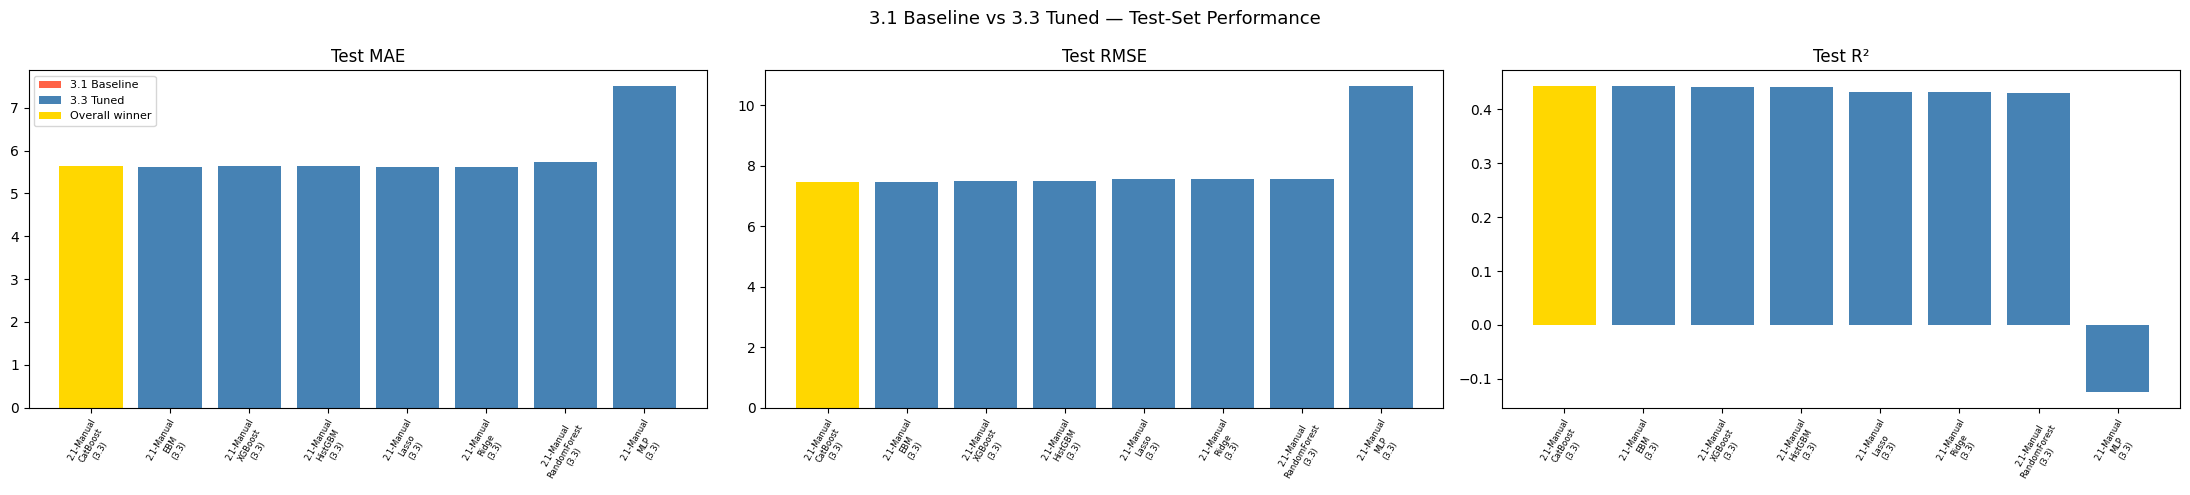


>>> OVERALL WINNER
    Source   : 3.3-Tuned
    Dataset  : 2.1-Manual
    Model    : CatBoost
    Test RMSE: 7.4683  |  Test R²: 0.4436

Sections 2–5 will analyse: source=3.3-Tuned, dataset=2.1-Manual, model=CatBoost


In [3]:
import pandas as pd

# ── Build combined comparison table ───────────────────────────────────────────
comparison_rows = []
for source, cache in [('3.1-Baseline', results_31), ('3.3-Tuned', results_33)]:
    for ds_label, models_dict in cache.items():
        for mdl_name, res in models_dict.items():
            comparison_rows.append({
                'Source':    source,
                'Dataset':   ds_label,
                'Model':     mdl_name,
                'CV RMSE':   round(res['cv_rmse'],  4),
                'CV R²':     round(res['cv_r2'],    4),
                'Test MAE':  round(res['test_mae'], 4),
                'Test RMSE': round(res['test_rmse'],4),
                'Test R²':   round(res['test_r2'],  4),
            })

comparison_df = pl.DataFrame(comparison_rows).sort('Test RMSE')

print('=== Combined Results: 3.1 Baseline vs 3.3 Tuned ===\n')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(comparison_df.to_pandas().reset_index(drop=True))

# ── Per-source summary ────────────────────────────────────────────────────────
print('\n=== Best per source ===')
for source in ['3.1-Baseline', '3.3-Tuned']:
    subset = comparison_df.filter(pl.col('Source') == source)
    if subset.is_empty():
        print(f'  {source}: no results loaded')
        continue
    best = subset.row(0, named=True)
    print(f'  {source:<15}  Best: {best["Dataset"]} × {best["Model"]:<22}  '
          f'Test RMSE={best["Test RMSE"]}  R²={best["Test R²"]}')

# ── Visual side-by-side bar chart ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

rows = comparison_df.to_dicts()
labels  = [f'{r["Dataset"]}\n{r["Model"]}\n({r["Source"][:3]})' for r in rows]
colors  = ['tomato' if r['Source'] == '3.1-Baseline' else 'steelblue' for r in rows]
colors[0] = 'gold'   # overall winner

fig, axes = plt.subplots(1, 3, figsize=(22, max(5, len(rows) * 0.35)))
fig.suptitle('3.1 Baseline vs 3.3 Tuned — Test-Set Performance', fontsize=13)

for ax, metric in zip(axes, ['Test MAE', 'Test RMSE', 'Test R²']):
    values = [r[metric] for r in rows]
    ax.bar(labels, values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=60, labelsize=6)

legend_handles = [
    mpatches.Patch(facecolor='tomato',    label='3.1 Baseline'),
    mpatches.Patch(facecolor='steelblue', label='3.3 Tuned'),
    mpatches.Patch(facecolor='gold',      label='Overall winner'),
]
axes[0].legend(handles=legend_handles, fontsize=8)
plt.tight_layout()
plt.show()

# ── RMSE improvement of best 3.3 vs best 3.1 ─────────────────────────────────
best_31 = comparison_df.filter(pl.col('Source') == '3.1-Baseline')
best_33 = comparison_df.filter(pl.col('Source') == '3.3-Tuned')
if not best_31.is_empty() and not best_33.is_empty():
    rmse_31 = best_31.row(0, named=True)['Test RMSE']
    rmse_33 = best_33.row(0, named=True)['Test RMSE']
    delta   = rmse_31 - rmse_33
    print(f'\n>>> HPO improvement: {delta:+.4f} RMSE  ({100*delta/rmse_31:+.1f}%)  '
          f'3.1 best={rmse_31:.4f}  →  3.3 best={rmse_33:.4f}')

# ── Pick overall winner for downstream analysis ───────────────────────────────
winner_row   = comparison_df.row(0, named=True)
best_source  = winner_row['Source']
best_dataset = winner_row['Dataset']
best_name    = winner_row['Model']

winner_cache = results_31 if best_source == '3.1-Baseline' else results_33

best_res      = winner_cache[best_dataset][best_name]
best_pipeline = best_res['pipeline']
X_train       = best_res['X_train']
X_test        = best_res['X_test']
y_train       = best_res['y_train']
y_test        = best_res['y_test']
y_pred        = best_res['y_pred']
feature_names = best_res['feature_names']
numeric_cols  = best_res['numeric_cols']
cat_cols      = best_res['cat_cols']

print(f'\n>>> OVERALL WINNER')
print(f'    Source   : {best_source}')
print(f'    Dataset  : {best_dataset}')
print(f'    Model    : {best_name}')
print(f'    Test RMSE: {winner_row["Test RMSE"]}  |  Test R²: {winner_row["Test R²"]}')
print(f'\nSections 2–5 will analyse: source={best_source}, dataset={best_dataset}, model={best_name}')

## 1.5 Low-Correlation Feature Analysis

Features with a very low absolute Pearson correlation with `health_gain` carry little linear signal and are candidates for removal or closer inspection.


=== All 48 numeric features sorted by |correlation| with health_gain ===



c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Feature,Pearson r,|r|
0,Liver Disease,-0.0018,0.0018
1,Cancer,-0.0039,0.0039
2,Pre-Op Q Living Arrangements_4,0.0050,0.0050
3,Pre-Op Q Living Arrangements_3,0.0051,0.0051
4,High Bp,0.0067,0.0067
5,Nervous System,-0.0073,0.0073
6,Arthritis,0.0086,0.0086
7,Kidney Disease,-0.0108,0.0108
8,depression_pain_interaction,-0.0143,0.0143
9,Stroke,-0.0147,0.0147


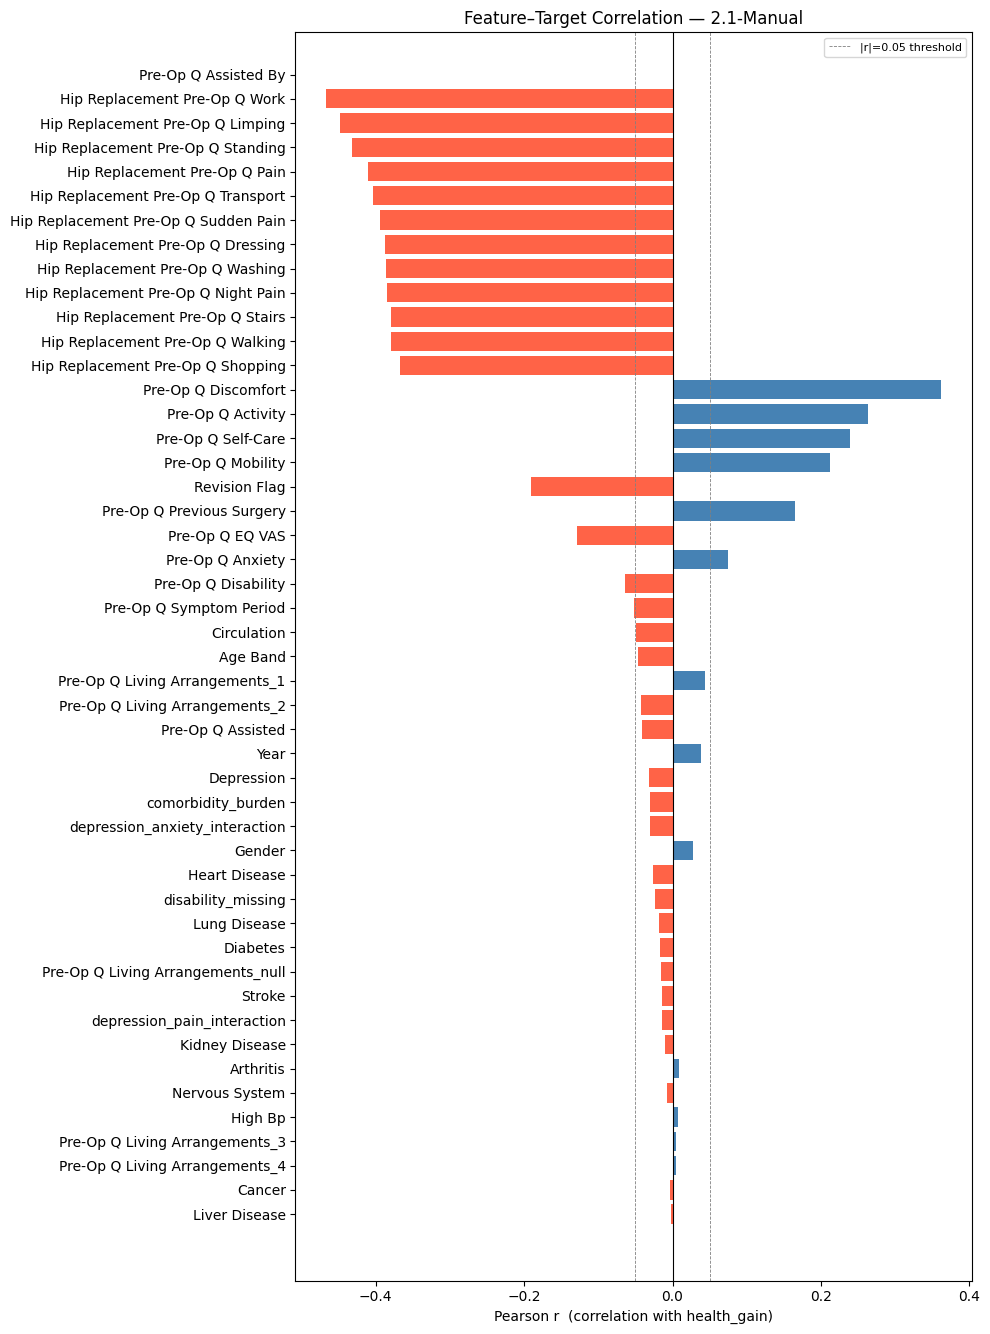


>>> Features with |r| < 0.05  (very low correlation with health_gain): 25


,Feature,Pearson r,|r|
0,Liver Disease,-0.0018,0.0018
1,Cancer,-0.0039,0.0039
2,Pre-Op Q Living Arrangements_4,0.0050,0.0050
3,Pre-Op Q Living Arrangements_3,0.0051,0.0051
4,High Bp,0.0067,0.0067
5,Nervous System,-0.0073,0.0073
6,Arthritis,0.0086,0.0086
7,Kidney Disease,-0.0108,0.0108
8,depression_pain_interaction,-0.0143,0.0143
9,Stroke,-0.0147,0.0147



Consider dropping or further investigating these before modelling.


In [4]:

import pandas as pd

# ── Pearson correlation of every numeric feature with the target ──────────────
train_pd = X_train[numeric_cols].to_pandas()
target_s = pd.Series(y_train, name='health_gain')

corr_rows = []
for col in numeric_cols:
    r = train_pd[col].corr(target_s)
    corr_rows.append({'Feature': col, 'Pearson r': round(r, 4), '|r|': round(abs(r), 4)})

corr_df = (
    pd.DataFrame(corr_rows)
    .sort_values('|r|')
    .reset_index(drop=True)
)

print(f'=== All {len(corr_df)} numeric features sorted by |correlation| with health_gain ===\n')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(corr_df)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig_h = max(6, len(corr_df) * 0.28)
plt.figure(figsize=(10, fig_h))
colors = ['tomato' if r < 0 else 'steelblue' for r in corr_df['Pearson r']]
plt.barh(corr_df['Feature'], corr_df['Pearson r'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline( 0.05, color='grey', linewidth=0.6, linestyle='--', label='|r|=0.05 threshold')
plt.axvline(-0.05, color='grey', linewidth=0.6, linestyle='--')
plt.xlabel('Pearson r  (correlation with health_gain)')
plt.title(f'Feature–Target Correlation — {best_dataset}')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Flag very low-correlation features (|r| < 0.05) ──────────────────────────
threshold = 0.05
low_corr  = corr_df[corr_df['|r|'] < threshold].reset_index(drop=True)

print(f'\n>>> Features with |r| < {threshold}  (very low correlation with health_gain): {len(low_corr)}')
if len(low_corr) > 0:
    display(low_corr)
    print('\nConsider dropping or further investigating these before modelling.')
else:
    n_bottom = max(3, len(corr_df) // 5)
    print(f'  None below {threshold}. Weakest {n_bottom} features:')
    display(corr_df.head(n_bottom))


## 2. Residual Analysis — Best Pipeline

Using the winning **(dataset, model)** pair identified above.

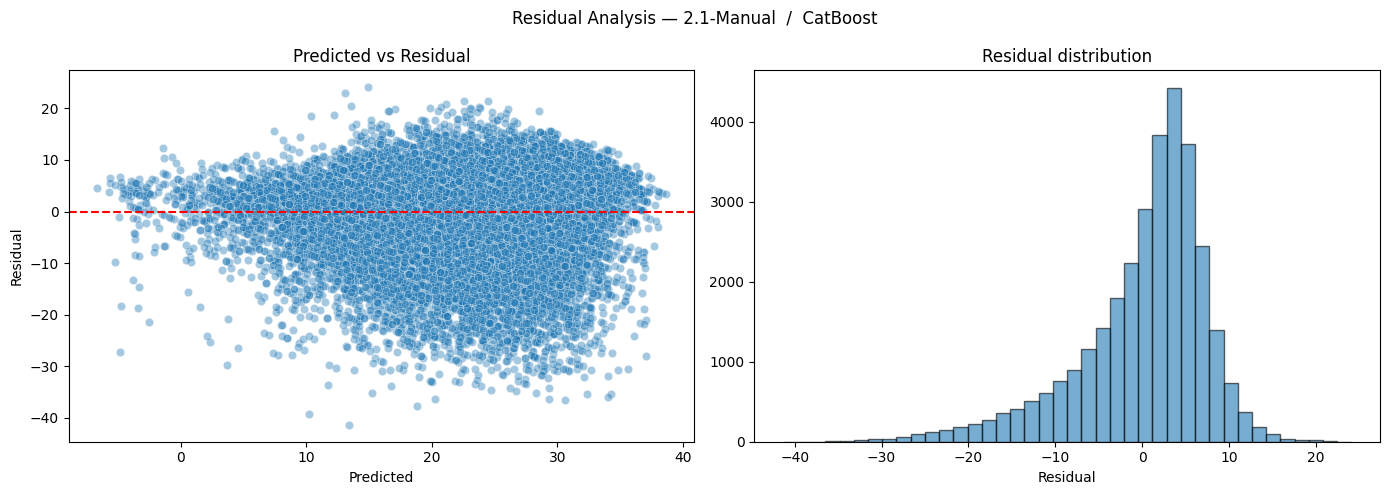

Residual stats: mean=0.1003  std=7.4676


In [5]:
resid = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Residual Analysis — {best_dataset}  /  {best_name}', fontsize=12)

sns.scatterplot(ax=axes[0], x=y_pred, y=resid, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Predicted vs Residual')

axes[1].hist(resid, bins=40, edgecolor='k', alpha=0.6)
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print(f'Residual stats: mean={resid.mean():.4f}  std={resid.std():.4f}')

## 3. Feature Importance & SHAP — Best Pipeline

Top 20 feature importances:
shape: (20, 2)
┌─────────────────────────────────┬────────────┐
│ feature                         ┆ importance │
│ ---                             ┆ ---        │
│ str                             ┆ f64        │
╞═════════════════════════════════╪════════════╡
│ Hip Replacement Pre-Op Q Limpi… ┆ 13.687888  │
│ Hip Replacement Pre-Op Q Sudde… ┆ 6.781738   │
│ Revision Flag                   ┆ 6.593089   │
│ Hip Replacement Pre-Op Q Work   ┆ 6.465338   │
│ Hip Replacement Pre-Op Q Dress… ┆ 6.262232   │
│ …                               ┆ …          │
│ Hip Replacement Pre-Op Q Stair… ┆ 2.370835   │
│ Pre-Op Q EQ VAS                 ┆ 2.364923   │
│ Pre-Op Q Anxiety                ┆ 2.214191   │
│ Pre-Op Q Symptom Period         ┆ 2.173951   │
│ Circulation                     ┆ 2.139164   │
└─────────────────────────────────┴────────────┘


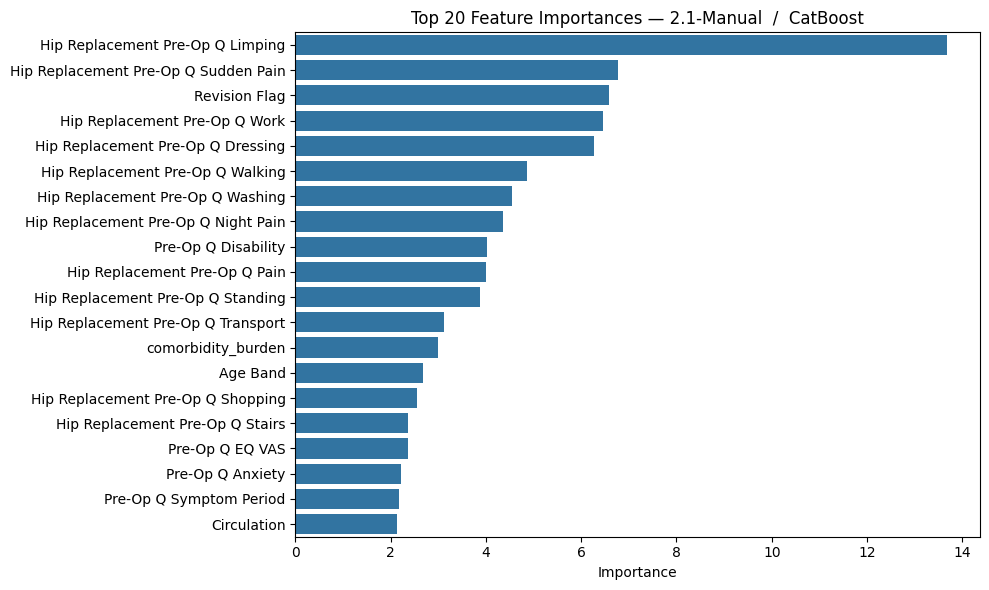


Running SHAP (may take a moment)...


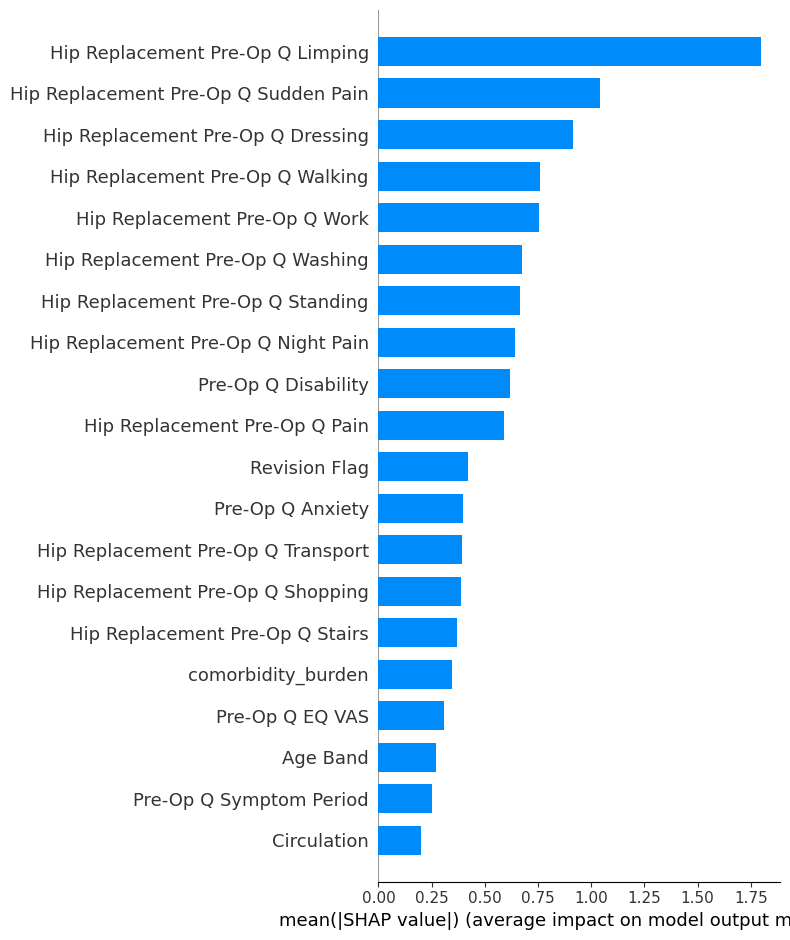

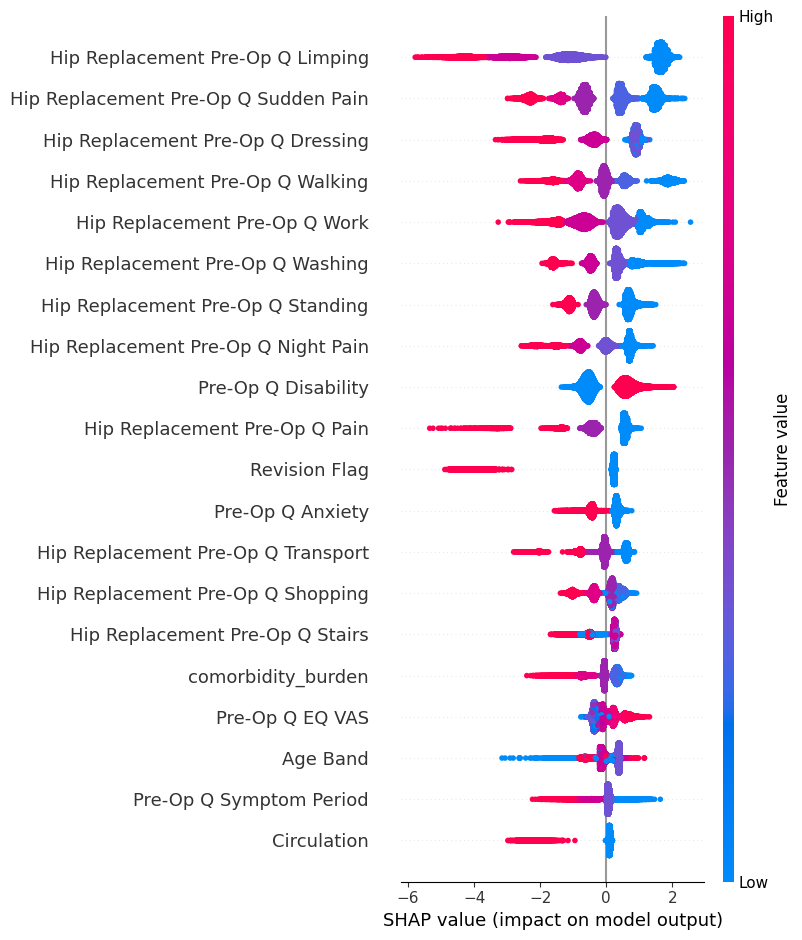

In [6]:

import pandas as pd

model_step   = best_pipeline.named_steps['model']
title_suffix = f'{best_dataset}  /  {best_name}'

# ── Tree models: feature importances ─────────────────────────────────────────
if hasattr(model_step, 'feature_importances_'):
    imp_df = (
        pl.DataFrame({'feature': feature_names, 'importance': model_step.feature_importances_})
        .sort('importance', descending=True)
    )
    print('Top 20 feature importances:')
    print(imp_df.head(20))

    top20 = imp_df.head(20)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top20['importance'].to_list(), y=top20['feature'].to_list())
    plt.title(f'Top 20 Feature Importances — {title_suffix}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# ── Linear models: coefficients ───────────────────────────────────────────────
elif hasattr(model_step, 'coef_'):
    coef_df = (
        pl.DataFrame({'feature': feature_names, 'coef': model_step.coef_})
        .with_columns(pl.col('coef').abs().alias('abs_coef'))
        .sort('abs_coef', descending=True)
    )
    top25_features = coef_df.head(25)['feature'].to_list()
    top25 = coef_df.filter(pl.col('feature').is_in(top25_features)).sort('coef')

    print('Top 25 features by absolute coefficient:')
    print(top25)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top25['coef'].to_list()]
    plt.figure(figsize=(10, 8))
    sns.barplot(x=top25['coef'].to_list(), y=top25['feature'].to_list(), palette=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Top 25 Feature Coefficients — {title_suffix}')
    plt.xlabel('Coefficient value')
    plt.tight_layout()
    plt.show()

else:
    print(f'No feature importance or coefficients for {best_name}.')

# ── SHAP ──────────────────────────────────────────────────────────────────────
def _xgb_shap_explanation(mdl, X_df):
    """
    XGBoost 2.x compatible SHAP via native pred_contribs — avoids the
    TreeExplainer base_score '[float]' ValueError entirely.
    Returns a shap.Explanation object.
    """
    import xgboost as xgb
    booster  = mdl.get_booster()
    dm       = xgb.DMatrix(X_df)
    contribs = booster.predict(dm, pred_contribs=True)   # (n, n_features+1)
    values   = contribs[:, :-1]                          # SHAP values
    base_val = float(contribs[0, -1])                    # bias / expected value
    return shap.Explanation(
        values       = values,
        base_values  = np.full(len(values), base_val),
        data         = X_df.values,
        feature_names = feature_names,
    )

if shap is not None:
    print('\nRunning SHAP (may take a moment)...')
    X_train_t = best_pipeline.named_steps['pre'].transform(X_train.to_pandas())
    X_test_t  = best_pipeline.named_steps['pre'].transform(X_test.to_pandas())

    X_train_shap = pd.DataFrame(X_train_t, columns=feature_names)
    X_test_shap  = pd.DataFrame(X_test_t,  columns=feature_names)

    if hasattr(model_step, 'get_booster'):
        # XGBoost: use native pred_contribs to bypass TreeExplainer base_score bug
        shap_values = _xgb_shap_explanation(model_step, X_test_shap)
    elif hasattr(model_step, 'feature_importances_'):
        explainer   = shap.TreeExplainer(model_step)
        shap_values = explainer(X_test_shap, check_additivity=False)
    elif hasattr(model_step, 'coef_'):
        explainer   = shap.LinearExplainer(model_step, X_train_shap)
        shap_values = explainer(X_test_shap)
    else:
        sample      = shap.sample(X_train_shap, min(100, len(X_train_shap)))
        explainer   = shap.KernelExplainer(model_step.predict, sample)
        shap_values = explainer(X_test_shap)

    shap.summary_plot(shap_values, feature_names=feature_names, plot_type='bar', show=True)
    shap.summary_plot(shap_values, feature_names=feature_names, show=True)
else:
    print('SHAP not available — restart kernel and re-run to activate.')


## 4. Dummy Patient Prediction — Best Pipeline

Simulate a median/mode patient from the winning dataset's training data, predict their health gain, and explain the key drivers.

Dummy patient built from training set: 2.1-Manual  /  CatBoost

=== Dummy Patient Profile ===
shape: (48, 2)
┌────────────────────────────────┬───────┐
│ Feature                        ┆ Value │
│ ---                            ┆ ---   │
│ str                            ┆ f64   │
╞════════════════════════════════╪═══════╡
│ Revision Flag                  ┆ 0.0   │
│ Year                           ┆ 1.0   │
│ Age Band                       ┆ 6.0   │
│ Gender                         ┆ 2.0   │
│ Pre-Op Q Assisted              ┆ 2.0   │
│ …                              ┆ …     │
│ Hip Replacement Pre-Op Q Work  ┆ 1.0   │
│ comorbidity_burden             ┆ 1.0   │
│ disability_missing             ┆ 0.0   │
│ depression_pain_interaction    ┆ 0.0   │
│ depression_anxiety_interaction ┆ 0.0   │
└────────────────────────────────┴───────┘

>>> Predicted Health Gain : 26.0229
    Training set mean     : 21.5894
    This patient is ABOVE average by 4.4335 points

=== Top 10 most important features 

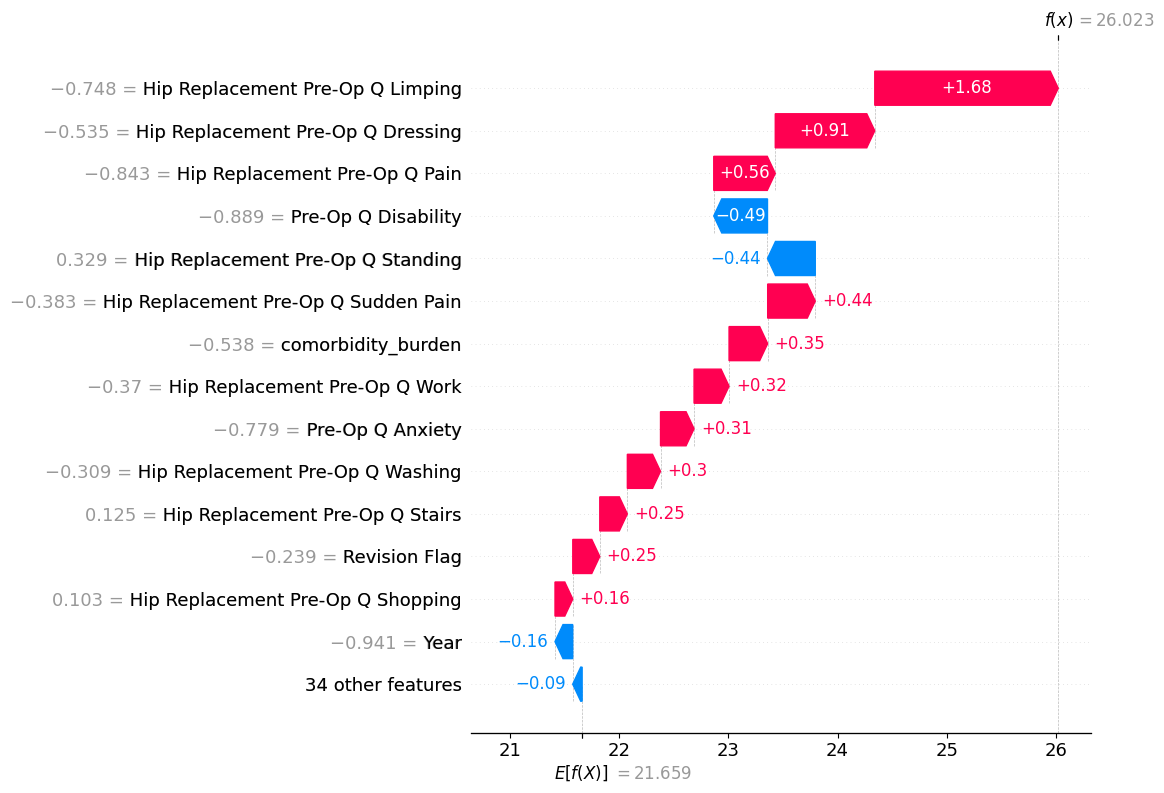


=== Plain English Summary ===
Dataset '2.1-Manual' with model 'CatBoost' predicts this patient will
gain 26.02 points on the knee health score after surgery.
This is higher than the average gain of 21.59 in that training set.


In [7]:

import pandas as pd

print(f'Dummy patient built from training set: {best_dataset}  /  {best_name}\n')

# ── Build representative patient using Polars native operations ───────────────
dummy_data = {}
for col in numeric_cols:
    dummy_data[col] = [X_train[col].median()]
for col in cat_cols:
    mode_series = X_train[col].mode()
    dummy_data[col] = [mode_series[0] if len(mode_series) > 0 else None]

dummy_pl = pl.DataFrame(dummy_data)
dummy_pd = dummy_pl.to_pandas()      # sklearn boundary

print('=== Dummy Patient Profile ===')
print(dummy_pl.transpose(include_header=True, header_name='Feature', column_names=['Value']))

# ── Predict (sklearn boundary) ────────────────────────────────────────────────
predicted_gain = best_pipeline.predict(dummy_pd)[0]
avg_gain       = float(np.mean(y_train))
diff           = predicted_gain - avg_gain
direction      = 'ABOVE' if diff > 0 else 'BELOW'

print(f'\n>>> Predicted Health Gain : {predicted_gain:.4f}')
print(f'    Training set mean     : {avg_gain:.4f}')
print(f'    This patient is {direction} average by {abs(diff):.4f} points\n')

# ── Explain contributions ─────────────────────────────────────────────────────
model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'coef_'):
    transformed   = best_pipeline.named_steps['pre'].transform(dummy_pd)[0]
    contributions = {f: float(c * t) for f, c, t in zip(feature_names, model_step.coef_, transformed)}
    total_abs     = sum(abs(v) for v in contributions.values())

    sorted_by_val = sorted(contributions.items(), key=lambda x: x[1], reverse=True)
    top_pos = sorted_by_val[:5]
    top_neg = sorted_by_val[-5:][::-1]

    print('=== Top 5 features INCREASING the predicted health gain ===')
    print(f'  {"Feature":<45} {"Raw value":<12} {"Contribution":>12}  {"% of total":>10}')
    print('  ' + '-' * 85)
    for feat, val in top_pos:
        raw  = dummy_pl[feat][0] if feat in dummy_pl.columns else 'encoded'
        pct  = 100 * val / total_abs
        print(f'  + {feat:<45} {str(raw):<12} {val:>+12.4f}  {pct:>9.1f}%')

    print(f'\n=== Top 5 features DECREASING the predicted health gain ===')
    print(f'  {"Feature":<45} {"Raw value":<12} {"Contribution":>12}  {"% of total":>10}')
    print('  ' + '-' * 85)
    for feat, val in top_neg:
        raw  = dummy_pl[feat][0] if feat in dummy_pl.columns else 'encoded'
        pct  = 100 * val / total_abs
        print(f'  - {feat:<45} {str(raw):<12} {val:>+12.4f}  {pct:>9.1f}%')

    # Bar chart — top 20 by absolute contribution with % labels
    sorted_abs = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
    bar_feats  = [f for f, _ in sorted_abs]
    bar_vals   = [contributions[f] for f in bar_feats]
    bar_pcts   = [100 * v / total_abs for v in bar_vals]
    bar_colors = ['steelblue' if v >= 0 else 'tomato' for v in bar_vals]

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(bar_feats[::-1], bar_vals[::-1], color=bar_colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Feature Contributions — {best_dataset}  /  {best_name}')
    ax.set_xlabel('Contribution  (coef × scaled value)')
    for bar, pct in zip(bars, bar_pcts[::-1]):
        x_pos = bar.get_width()
        ax.text(
            x_pos + (0.002 * ax.get_xlim()[1] if x_pos >= 0 else -0.002 * ax.get_xlim()[1]),
            bar.get_y() + bar.get_height() / 2,
            f'{pct:+.1f}%',
            va='center', ha='left' if x_pos >= 0 else 'right', fontsize=8,
        )
    plt.tight_layout()
    plt.show()

elif hasattr(model_step, 'feature_importances_'):
    imp_df = (
        pl.DataFrame({'feature': feature_names, 'importance': model_step.feature_importances_})
        .sort('importance', descending=True)
    )
    total_imp = imp_df['importance'].sum()
    print('=== Top 10 most important features ===')
    print(f'  {"Feature":<45} {"Patient value":<15} {"Importance":>10}  {"% of total":>10}')
    print('  ' + '-' * 85)
    for row in imp_df.head(10).iter_rows(named=True):
        feat, imp = row['feature'], row['importance']
        raw = dummy_pl[feat][0] if feat in dummy_pl.columns else 'encoded'
        pct = 100 * imp / total_imp
        print(f'  {feat:<45} {str(raw):<15} {imp:>10.4f}  {pct:>9.1f}%')

# ── SHAP waterfall ────────────────────────────────────────────────────────────
def _xgb_shap_explanation(mdl, X_df):
    """
    XGBoost 2.x compatible SHAP via native pred_contribs — avoids the
    TreeExplainer base_score '[float]' ValueError entirely.
    Returns a shap.Explanation object.
    """
    import xgboost as xgb
    booster  = mdl.get_booster()
    dm       = xgb.DMatrix(X_df)
    contribs = booster.predict(dm, pred_contribs=True)   # (n, n_features+1)
    values   = contribs[:, :-1]                          # SHAP values
    base_val = float(contribs[0, -1])                    # bias / expected value
    return shap.Explanation(
        values        = values,
        base_values   = np.full(len(values), base_val),
        data          = X_df.values,
        feature_names = feature_names,
    )

if shap is not None:
    X_train_t = best_pipeline.named_steps['pre'].transform(X_train.to_pandas())
    X_dummy_t = best_pipeline.named_steps['pre'].transform(dummy_pd)

    X_train_shap = pd.DataFrame(X_train_t, columns=feature_names)
    X_dummy_shap = pd.DataFrame(X_dummy_t, columns=feature_names)

    if hasattr(model_step, 'get_booster'):
        # XGBoost: use native pred_contribs to bypass TreeExplainer base_score bug
        shap_vals = _xgb_shap_explanation(model_step, X_dummy_shap)
    elif hasattr(model_step, 'feature_importances_'):
        explainer = shap.TreeExplainer(model_step)
        shap_vals = explainer(X_dummy_shap, check_additivity=False)
    elif hasattr(model_step, 'coef_'):
        explainer = shap.LinearExplainer(model_step, X_train_shap)
        shap_vals = explainer(X_dummy_shap)
    else:
        sample    = shap.sample(X_train_shap, min(100, len(X_train_shap)))
        explainer = shap.KernelExplainer(model_step.predict, sample)
        shap_vals = explainer(X_dummy_shap)

    sv             = shap_vals[0].values
    total_abs_shap = np.abs(sv).sum()
    shap_dict      = {f: float(v) for f, v in zip(feature_names, sv)}
    shap_top       = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:15]

    print('\n=== SHAP Feature Contributions (%) for Dummy Patient ===')
    print(f'  {"Feature":<45} {"SHAP value":>12}  {"% of |SHAP| total":>18}')
    print('  ' + '-' * 80)
    for feat, val in shap_top:
        pct  = 100 * abs(val) / total_abs_shap
        sign = '+' if val >= 0 else '-'
        print(f'  {sign} {feat:<44} {val:>+12.4f}  {pct:>17.1f}%')

    print('\n=== SHAP Waterfall (dummy patient) ===')
    shap.plots.waterfall(shap_vals[0], max_display=15, show=True)
else:
    print('\nTip: restart kernel and re-run to enable SHAP waterfall.')

print('\n=== Plain English Summary ===')
print(f"Dataset '{best_dataset}' with model '{best_name}' predicts this patient will")
print(f"gain {predicted_gain:.2f} points on the knee health score after surgery.")
print(f"This is {'higher' if diff > 0 else 'lower'} than the average gain of {avg_gain:.2f} in that training set.")


## 5. Save All Models and Metrics

Save the best pipeline for **each dataset** and a combined comparison CSV.

In [8]:

out_dir = Path('./models')
out_dir.mkdir(parents=True, exist_ok=True)

# ── Save every (dataset × model) pipeline ────────────────────────────────────
for ds_label, models_dict in all_results.items():
    for mdl_name, res in models_dict.items():
        safe_label = ds_label.replace('/', '-').replace(' ', '_')
        pipe_path  = out_dir / f'3.1-{safe_label}-{mdl_name}.joblib'
        joblib.dump(res['pipeline'], pipe_path)
        print(f'Saved: {pipe_path}')

# ── Save comparison CSV using Polars ─────────────────────────────────────────
comparison_path = out_dir / '3.1-comparison-metrics.csv'
comparison_df.write_csv(str(comparison_path))
print(f'\nSaved comparison table: {comparison_path}')

# ── Print final winner ────────────────────────────────────────────────────────
print(f'\n{"=" * 50}')
print(f'  OVERALL WINNER')
print(f'  Dataset  : {best_dataset}')
print(f'  Model    : {best_name}')
print(f'  Test RMSE: {winner_row["Test RMSE"]}  |  R²: {winner_row["Test R²"]}')
print(f'{"=" * 50}')


OSError: [Errno 22] Invalid argument: 'models\\3.1-3.3-Tuned|2.1-Manual-Ridge.joblib'